In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

In [2]:
# ── 1. Load Dataset ──────────────────────────────────────────
train_path = "datasets/mnist/train.csv"
test_path  = "datasets/mnist/test.csv"

if not os.path.exists(train_path) or not os.path.exists(test_path):
    print("❌ Dataset not found!")
    print("   Place train.csv and test.csv inside: datasets/mnist/")
    exit()

print("✅ Loading datasets...")
mnist_train = pd.read_csv(train_path)
mnist_test  = pd.read_csv(test_path)

print(f"   Train shape : {mnist_train.shape}")
print(f"   Test shape  : {mnist_test.shape}")

✅ Loading datasets...
   Train shape : (42000, 785)
   Test shape  : (28000, 784)


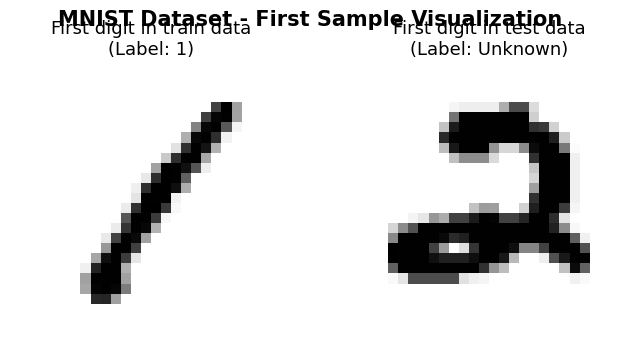

In [3]:
# ── 2. Visualize First Digits ─────────────────────────────────
train_data_digit1  = np.asarray(mnist_train.iloc[0:1, 1:]).reshape(28, 28)
test_data_digit1   = np.asarray(mnist_test.iloc[0:1, ]).reshape(28, 28)
train_label_1      = mnist_train.iloc[0, 0]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(train_data_digit1, cmap=plt.cm.gray_r)
plt.title(f"First digit in train data\n(Label: {train_label_1})", fontsize=13)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(test_data_digit1, cmap=plt.cm.gray_r)
plt.title("First digit in test data\n(Label: Unknown)", fontsize=13)
plt.axis('off')

plt.suptitle("MNIST Dataset - First Sample Visualization", fontsize=15, fontweight='bold')
plt.show(block=False)   # ← doesn't stop the program
plt.pause(7)            # ← shows plot for 7 seconds then continues
plt.close()

In [4]:
# ── 3. Feature Engineering ────────────────────────────────────
print("\n✅ Splitting features and labels...")
X_train = mnist_train.iloc[:, 1:]    # pixel values (784 columns)
Y_train = mnist_train.iloc[:, 0]     # labels (digit 0–9)

print(f"   X_train shape : {X_train.shape}")
print(f"   Y_train shape : {Y_train.shape}")

# ── 4. Build & Train ANN Model ────────────────────────────────
print("\n✅ Building ANN model...")
nn_model = MLPClassifier(hidden_layer_sizes=(50))

print("⏳ Training... (this may take a minute)")
nn_model.fit(X_train, Y_train)
print("✅ Training complete!")


✅ Splitting features and labels...
   X_train shape : (42000, 784)
   Y_train shape : (42000,)

✅ Building ANN model...
⏳ Training... (this may take a minute)
✅ Training complete!


In [6]:
# ── 5. Predict First Test Digit ───────────────────────────────
prediction = nn_model.predict(mnist_test.iloc[0:1, ])
print(f"\n🔢 Predicted digit for first test image: {prediction[0]}")

# ── 6. Check Overall Accuracy ─────────────────────────────────
train_accuracy = nn_model.score(X_train, Y_train) * 100
print(f"📊 Training Accuracy: {train_accuracy:.2f}%")

# report based on tain data
train_predictions = nn_model.predict(X_train)  # ✅ predict all 42000
print(classification_report(Y_train, train_predictions))


🔢 Predicted digit for first test image: 2
📊 Training Accuracy: 98.55%
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4132
           1       1.00      0.99      1.00      4684
           2       0.99      0.98      0.99      4177
           3       0.97      0.98      0.97      4351
           4       1.00      0.98      0.99      4072
           5       0.98      0.99      0.99      3795
           6       1.00      0.99      0.99      4137
           7       1.00      0.98      0.99      4401
           8       0.97      0.99      0.98      4063
           9       0.96      0.99      0.97      4188

    accuracy                           0.99     42000
   macro avg       0.99      0.99      0.99     42000
weighted avg       0.99      0.99      0.99     42000

